In [1]:
# This is what I'm gonna need for the wavelet transform
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils

# This is for the data preprocessing and the segmentation
sys.path.append('../scripts')
import utils_2d_v3 as two
import plot_tools as pt
import utils_AWE as AWE

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib import cm
import time

plt.style.use("../latex_default_AMT.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = '../data/pert_airs_l1_2022_015.nc'
ds = xr.open_dataset(data_path)

In [3]:
ds

<xarray.Dataset> Size: 187MB
Dimensions:           (NTRACK: 32400, NXTRACK: 90)
Dimensions without coordinates: NTRACK, NXTRACK
Data variables: (12/13)
    time              (NTRACK, NXTRACK) float64 23MB ...
    lon               (NTRACK, NXTRACK) float64 23MB ...
    lat               (NTRACK, NXTRACK) float64 23MB ...
    bt_8mu            (NTRACK, NXTRACK) float32 12MB ...
    bt_4mu            (NTRACK, NXTRACK) float32 12MB ...
    bt_4mu_pt         (NTRACK, NXTRACK) float32 12MB ...
    ...                ...
    bt_15mu_low       (NTRACK, NXTRACK) float32 12MB ...
    bt_15mu_low_pt    (NTRACK, NXTRACK) float32 12MB ...
    bt_15mu_low_var   (NTRACK, NXTRACK) float32 12MB ...
    bt_15mu_high      (NTRACK, NXTRACK) float32 12MB ...
    bt_15mu_high_pt   (NTRACK, NXTRACK) float32 12MB ...
    bt_15mu_high_var  (NTRACK, NXTRACK) float32 12MB ...

# Second Antarctic Overpass

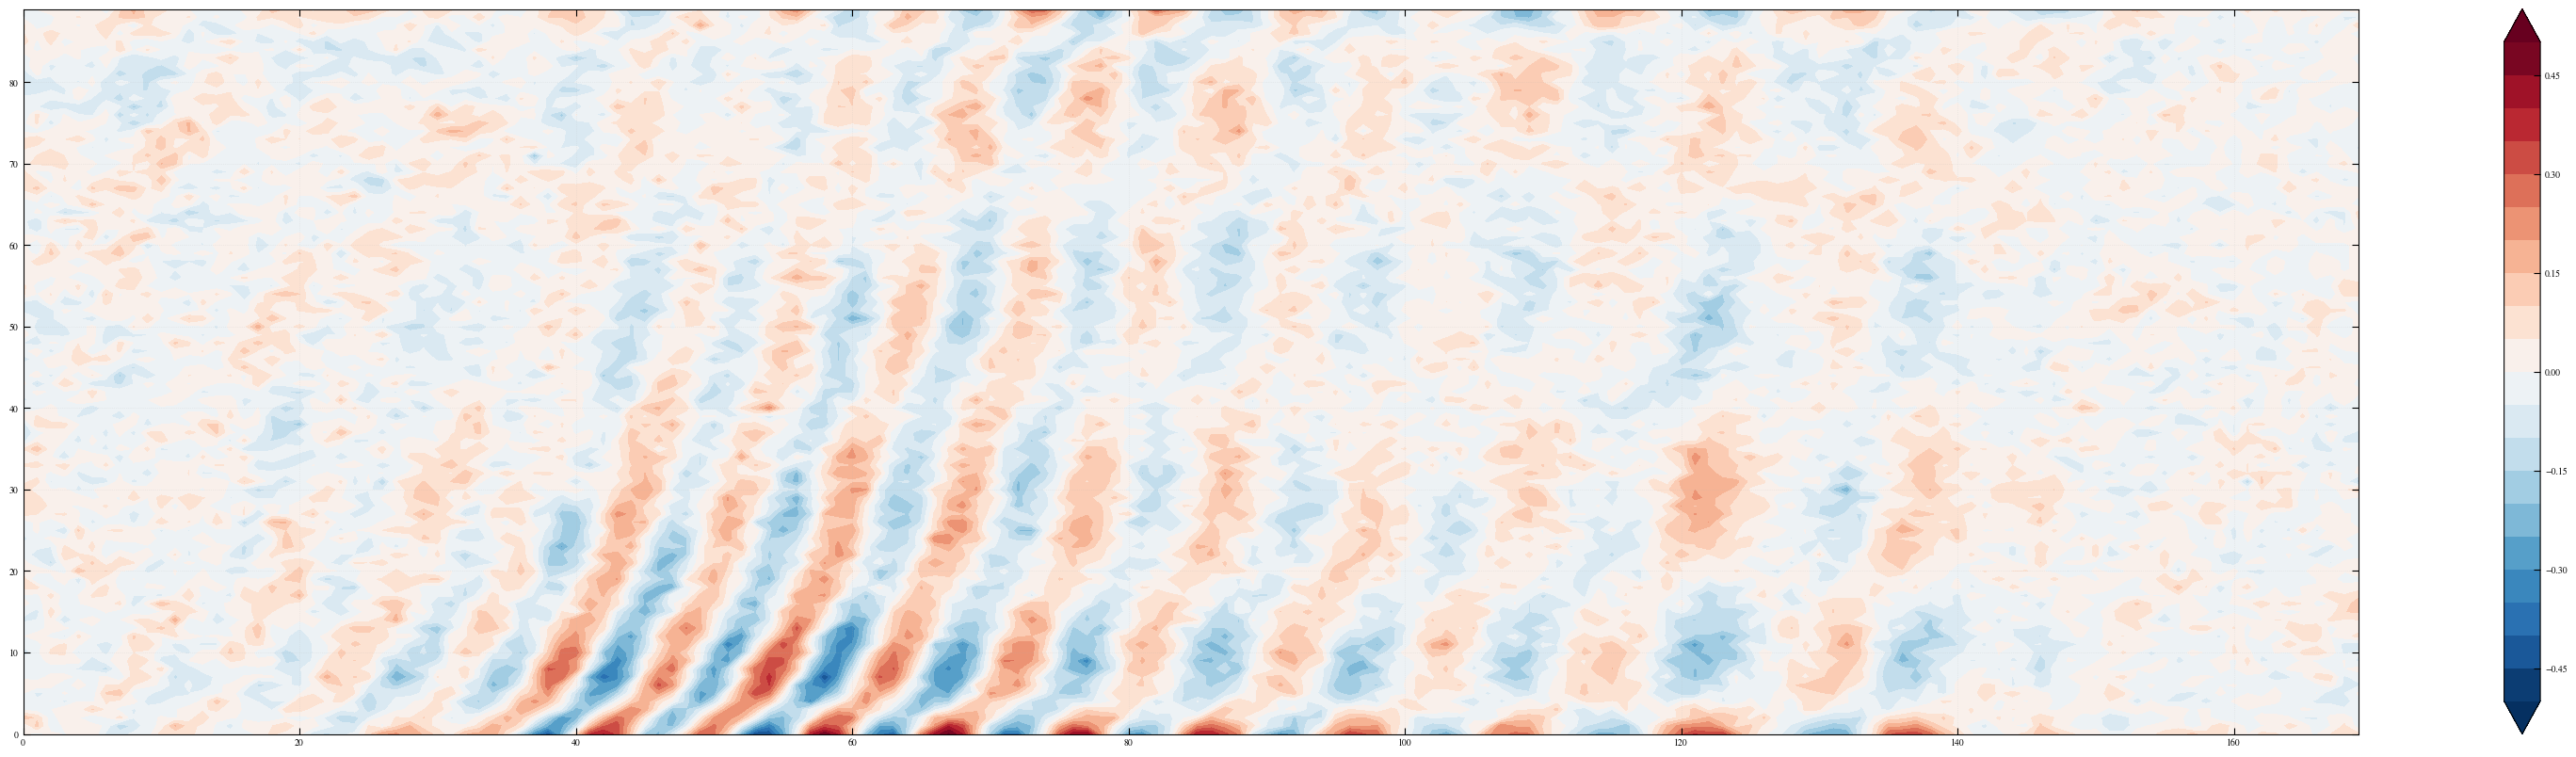

In [52]:
fig=plt.figure(figsize=(40,10))
plot_T = plt.contourf(ds['bt_4mu_pt'].isel(NTRACK=slice(17_480,17_650)).T,levels=np.linspace(-0.5,0.5,21),cmap='RdBu_r',extend='both')
plt.colorbar(plot_T)

In [53]:
#orig = ds["bt_4mu_pt"].isel(NTRACK=slice(15_100,15_500))
track_slice = slice(17_480,17_650)
orig = ds["bt_4mu_pt"].isel(NTRACK=track_slice)
orig_copy = orig.copy()
BI_high, BI_low = two.BG_removal(orig_copy.values)
dx, dy = 20_000, 20_000
nx, ny = orig['NTRACK'].size, orig['NXTRACK'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

print(f"Data size: {signal.shape[0]:.0f}x{signal.shape[1]:.0f}")

Data size: 170x90


In [54]:
s0 = 2 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 31

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 10},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

params = {
    "Smallest scale (s0)": f"{s0:.0f}",
    "Largest scale (s1)": f"{s1:.0f}",
    "Scale sampling (dj)": f"{dj:.3f}",
    "Number of scales (js)": f"{js:.0f}",
    "Number of azimuth angles (jt)": f"{jt:.0f}",
    "Non-dimensional frequency": f"{cwt_result['opts']['param']:.2f}",
}
label_width = max(len(label) for label in params)
for label, value in params.items():
    print(f"{label:<{label_width}} : {value}")

/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 20 km and the smallest wavelength you analyze is 25 km.
The data domain is at least 1800 km and the largest wavelength you analyze is 478 km.
Smallest scale (s0)           : 2
Largest scale (s1)            : 45
Scale sampling (dj)           : 0.125
Number of scales (js)         : 35
Number of azimuth angles (jt) : 31
Non-dimensional frequency     : 10.00


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


In [55]:
# Denoising
noise_level = 0.03 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=4*noise_level,sMAD_threshold=None,mean_axis=(1,2,3))

Text(0.03, 0.94, 'c')

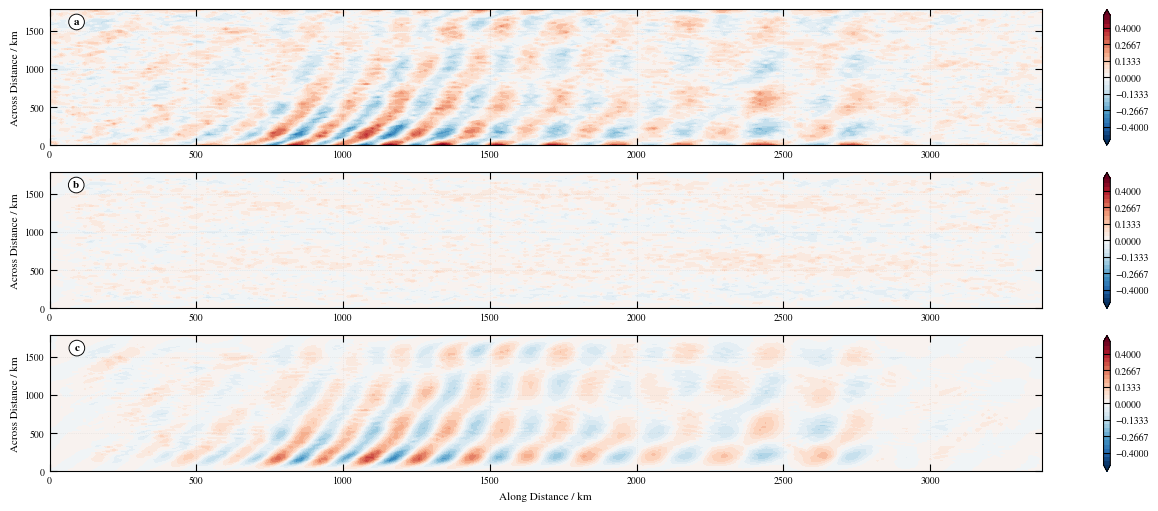

In [56]:
data_lev = np.linspace(-0.4,0.4,31)
fig = plt.figure(figsize=(16,6))
ax1 = fig.add_subplot(311)
plot_orig = ax1.contourf(x,y,orig.T,levels=data_lev,extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_orig)

ax2 = fig.add_subplot(312)
plot_dirt = ax2.contourf(x,y,BI_low.T+signal.T-wavy_stuff.T+np.mean(orig.values),levels=data_lev,extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_dirt)

ax3 = fig.add_subplot(313)
plot_wave = ax3.contourf(x,y,wavy_stuff.T,levels=data_lev,extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_wave)

ax3.set_xlabel('Along Distance / km')
ax1.set_ylabel('Across Distance / km')
ax2.set_ylabel('Across Distance / km')
ax3.set_ylabel('Across Distance / km')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/2D_example_AWE_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

In [57]:
WAS        = np.abs(denoised_cwt['decomposition'])
start_time = time.time()
seg_v1     = two.wavefield_segmentation_2d(WAS,0.1*noise_level,connectivity=1)
print("--- %s seconds ---" % (time.time() - start_time))
print('Identified', np.max(seg_v1), 'initial wave packets!')

k     = 2 * np.pi / cwt_result["period"]
theta = cwt_result["theta"]
eps   = np.abs(np.diff(np.log(k)))[0]*np.sqrt(2)
labels, cluster_labels = two.find_clusters_logk_theta(denoised_cwt, seg_v1, eps=eps)
cluster_map            = two.build_cluster_map_with_noise(labels,cluster_labels)
seg_v2                 = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Number of wave packets after Clustering', np.max(seg_v2))

--- 66.18564987182617 seconds ---
Identified 304 initial wave packets!


In [59]:
seg_v3 = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Final number of wave packets: 4


Text(0, 0.5, 'Latitude')

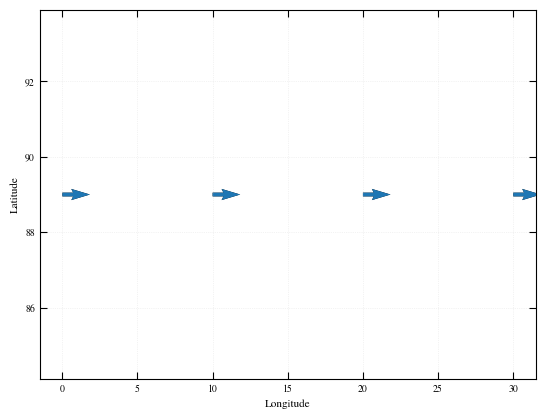

In [178]:
k_along = np.asarray([1, 1, 1, 1])
l_across = np.asarray([0, 0, 0, 0])
lon = np.asarray([0, 10, 20, 30])
lat = np.asarray([89, 89, 89, 89])
k_east, k_north = AWE.rotate_wave_vector(l_across, k_along, lat, lon)
plt.quiver(lon, lat, k_along, l_across)
plt.quiver(lon, lat, k_east, k_north, color='tab:blue')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [196]:
shape

slice(17480, 17650, None)

In [201]:

R = 6371000.0  # Erdradius in m

def get_track_unit_vectors(lat, lon):
    """
    lat, lon: 2D arrays oder 1D arrays entlang des Tracks
    Erwartung: along-track ist Achse 0
    Rückgabe:
        e_along_east, e_along_north,
        e_across_east, e_across_north
    """

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    # zentrale Differenzen entlang along-track
    dlat = np.zeros_like(lat_rad)
    dlon = np.zeros_like(lon_rad)

    dlat[1:-1] = lat_rad[2:] - lat_rad[:-2]
    dlon[1:-1] = lon_rad[2:] - lon_rad[:-2]

    # Ränder: einfache Differenzen
    dlat[0] = lat_rad[1] - lat_rad[0]
    dlat[-1] = lat_rad[-1] - lat_rad[-2]
    dlon[0] = lon_rad[1] - lon_rad[0]
    dlon[-1] = lon_rad[-1] - lon_rad[-2]

    # auf -pi...pi falten, falls Datumsgrenze
    dlon = (dlon + np.pi) % (2*np.pi) - np.pi

    dx = R * np.cos(lat_rad) * dlon   # East
    dy = R * dlat                     # North

    norm = np.sqrt(dx**2 + dy**2)
    norm[norm == 0] = np.nan

    e_along_e = dx / norm
    e_along_n = dy / norm

    # 90° Rotation
    e_across_e = -e_along_n
    e_across_n =  e_along_e

    return e_along_e, e_along_n, e_across_e, e_across_n

(2, 9)

In [221]:
lon = ds["lon"].isel(NTRACK=slice(17_480,17_540)).values[::10,::10]
lat = ds["lat"].isel(NTRACK=slice(17_480,17_540)).values[::10,::10]

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# zentrale Differenzen entlang along-track
dlat = np.zeros_like(lat_rad)
dlon = np.zeros_like(lon_rad)

dlat[1:-1] = lat_rad[2:] - lat_rad[:-2]
dlon[1:-1] = lon_rad[2:] - lon_rad[:-2]

# Ränder: einfache Differenzen
dlat[0] = lat_rad[1] - lat_rad[0]
dlat[-1] = lat_rad[-1] - lat_rad[-2]
dlon[0] = lon_rad[1] - lon_rad[0]
dlon[-1] = lon_rad[-1] - lon_rad[-2]

# auf -pi...pi falten, falls Datumsgrenze
dlon = (dlon + np.pi) % (2*np.pi) - np.pi

R = 6371000.0  # Erdradius in m

dx = R * np.cos(lat_rad) * dlon   # East
dy = R * dlat                     # North

In [223]:
dy

array([[-176647.33666849, -174759.14352456, -170787.2047585 ,
        -166493.55830203, -162080.63928753, -157524.12289872,
        -152217.94068788, -146003.39525411, -137849.88932943],
       [-353242.80429915, -348901.55091394, -340100.38737921,
        -330697.60874909, -321126.66520733, -311217.75840107,
        -300025.88345654, -286910.98946517, -269895.29578261],
       [-353120.56400581, -347493.85404725, -336707.40734684,
        -325452.95454139, -314112.03434453, -302576.51509602,
        -290018.36092474, -275641.67602488, -257219.66188833],
       [-353001.27309659, -345630.44985747, -332195.58488049,
        -318580.96768673, -305335.34862056, -292050.55854952,
        -277926.41746101, -261935.94906977, -242190.13899193],
       [-352928.98030237, -343018.91454991, -325967.40028889,
        -309329.7901678 , -293770.44593351, -278360.93564814,
        -262560.53041275, -245192.01445299, -224355.70842928],
       [-176452.80358093, -170739.91135031, -161166.04013454,
   

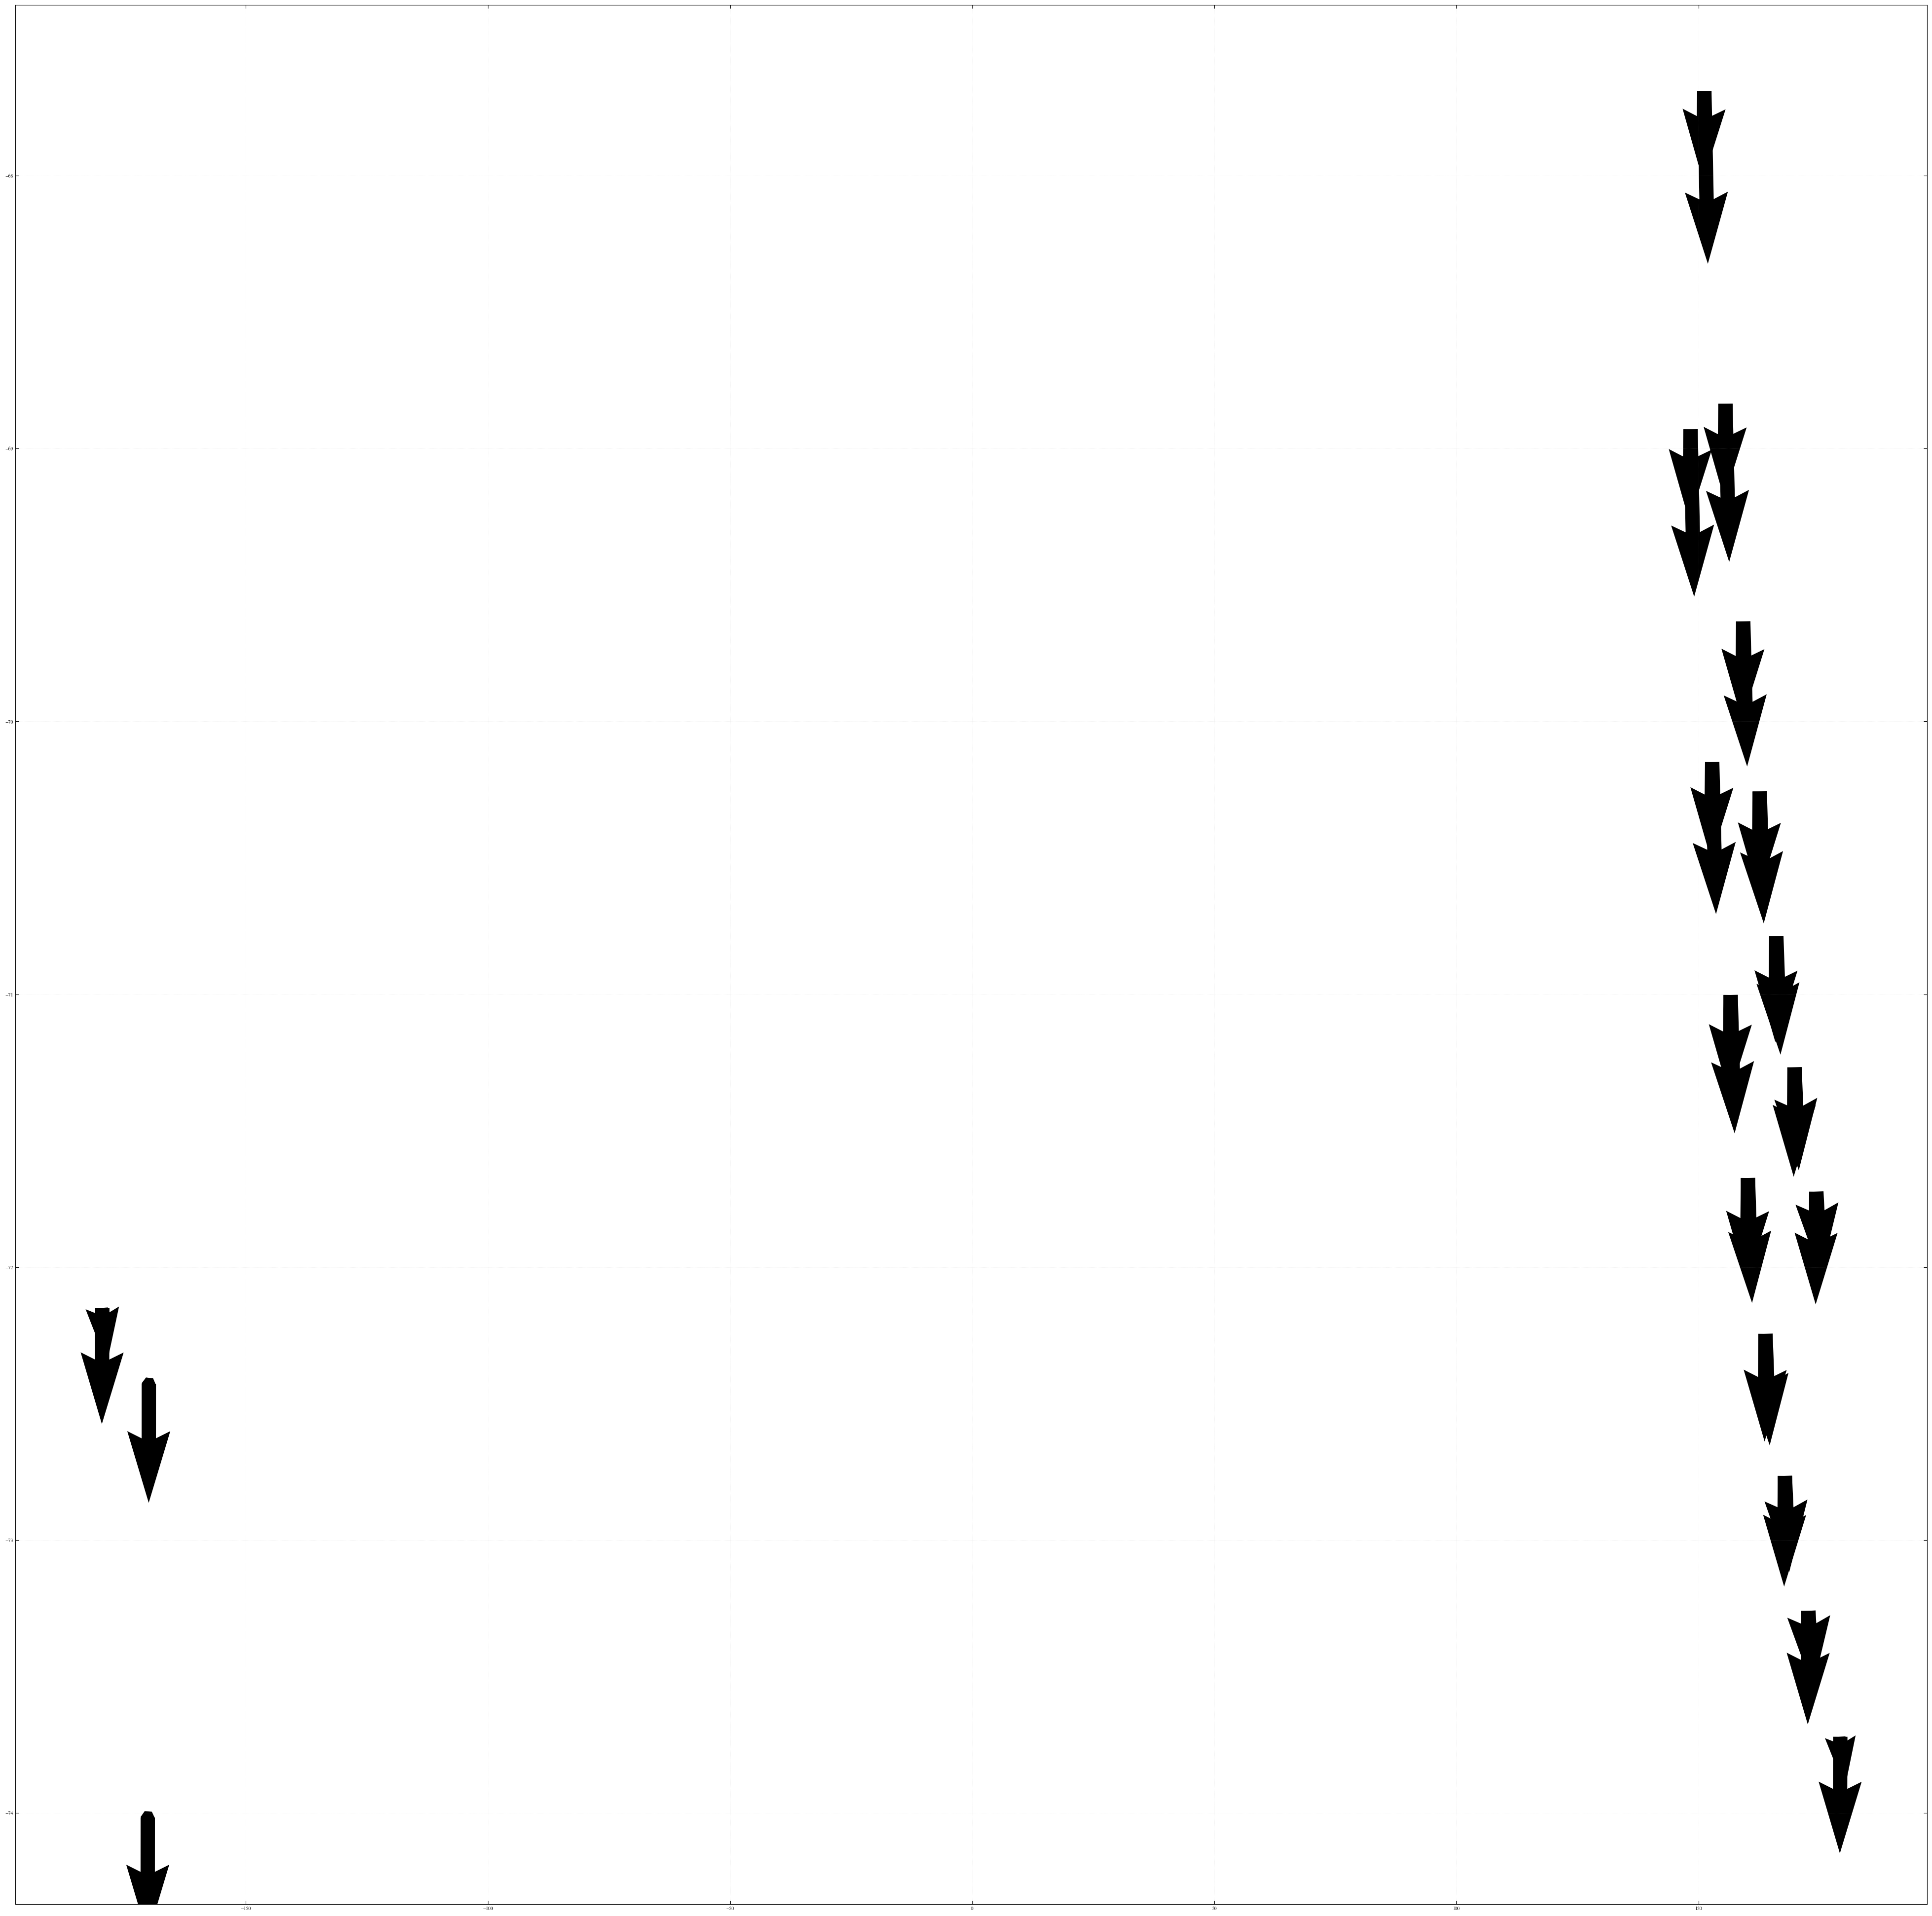

In [224]:
lon = ds["lon"].isel(NTRACK=slice(17_480,17_500)).values[::10,::10]
lat = ds["lat"].isel(NTRACK=slice(17_480,17_500)).values[::10,::10]

e_along_e, e_along_n, e_across_e, e_across_n = AWE.get_track_unit_vectors(lat, lon)

fig, ax = plt.subplots(1,1,figsize=(50, 50))
plot_th_1 = ax.quiver(np.asarray(lon), np.asarray(lat), e_along_e, e_along_n, rasterized=True, angles='xy', scale_units='xy')
plot_th_1 = ax.quiver(np.asarray(lon), np.asarray(lat), e_across_e, e_across_n, rasterized=True, angles='xy', scale_units='xy')
#plot_th_1 = ax.quiver(np.asarray(lon), np.asarray(lat), k_east, k_north, color='tab:blue', transform=data_crs, rasterized=True, angles='xy', scale_units='xy')

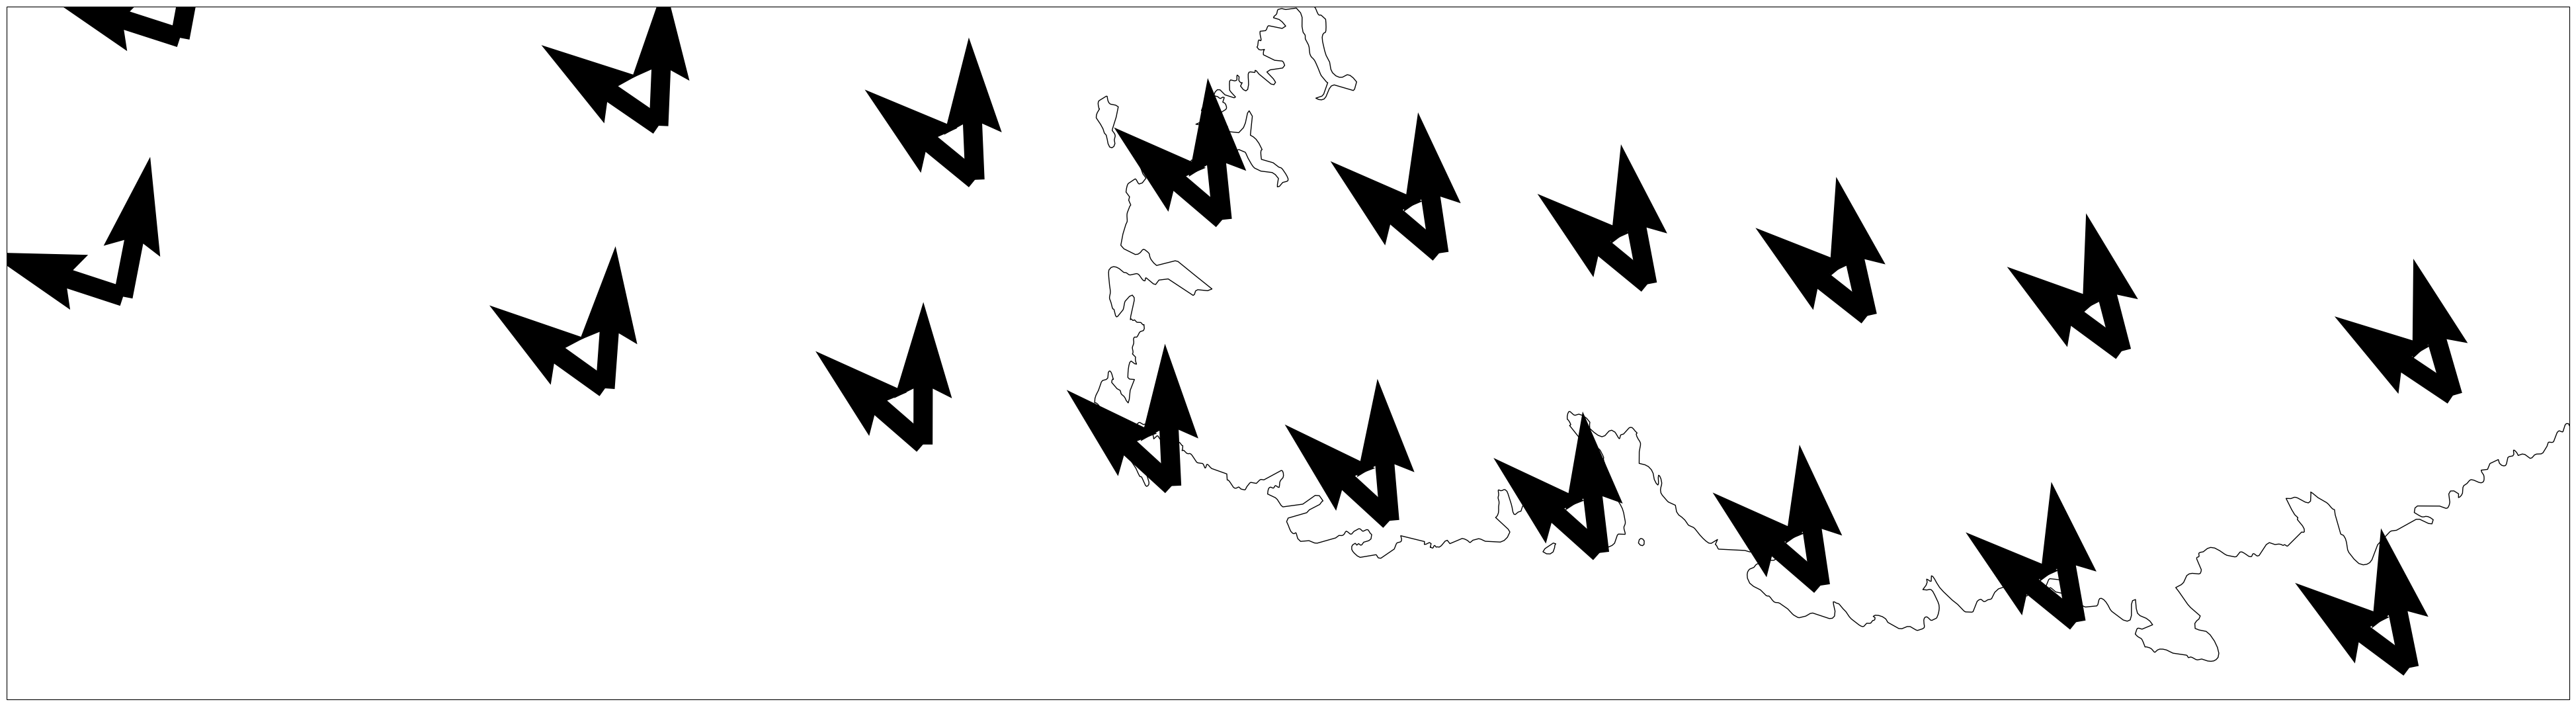

In [200]:
lon = ds["lon"].isel(NTRACK=slice(17_480,17_500)).values[::10,::10]
lat = ds["lat"].isel(NTRACK=slice(17_480,17_500)).values[::10,::10]

e_along_e, e_along_n, e_across_e, e_across_n = AWE.get_track_unit_vectors(lat, lon)

central_lon = 0
central_lat = -80
proj = ccrs.Stereographic(central_longitude=central_lon, central_latitude=central_lat)
data_crs = ccrs.PlateCarree()
fig, ax = plt.subplots(1,1,figsize=(50, 50),subplot_kw={"projection": proj})
plot_th_1 = ax.quiver(np.asarray(lon), np.asarray(lat), e_along_e, e_along_n, transform=data_crs, rasterized=True, angles='xy', scale_units='xy')
plot_th_1 = ax.quiver(np.asarray(lon), np.asarray(lat), e_across_e, e_across_n, transform=data_crs, rasterized=True, angles='xy', scale_units='xy')
ax.coastlines()
#plot_th_1 = ax.quiver(np.asarray(lon), np.asarray(lat), k_east, k_north, color='tab:blue', transform=data_crs, rasterized=True, angles='xy', scale_units='xy')

In [129]:
recon_WP, amp_WP, k_along_WP, k_across_WP = two.recon_allWP_2d(denoised_cwt, seg_v3)
k_east, k_north = AWE.rotate_wave_vector(k_across_WP, k_along_WP, lat.values, lon.values)
prop_mask = k_east < 0
k_north[prop_mask]*=-1
k_east[prop_mask]*=-1
lh_WP, th_WP = two.kxky_2_lhtheta(k_east,k_north)

100%|██████████| 15300/15300 [00:00<00:00, 25250.95it/s]


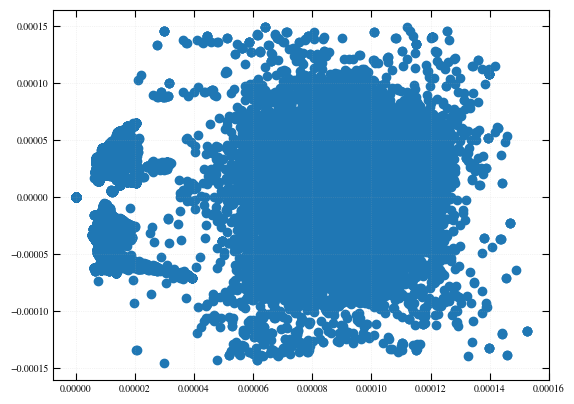

In [130]:
plt.scatter(k_along_WP,k_across_WP)

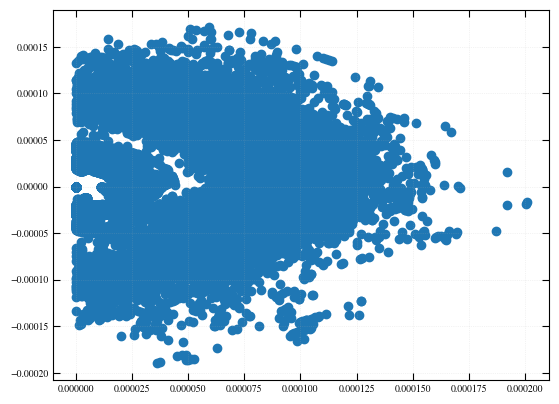

In [137]:
plt.scatter(k_east,k_north)

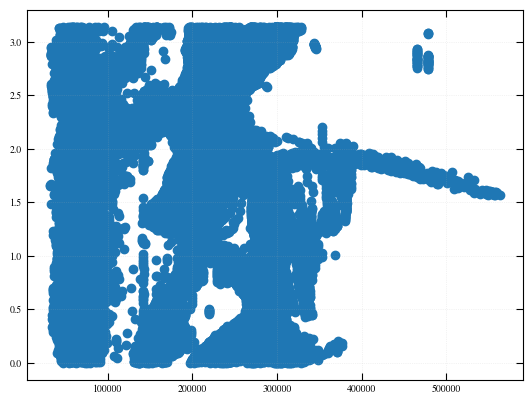

In [138]:
plt.scatter(lh_WP,th_WP)

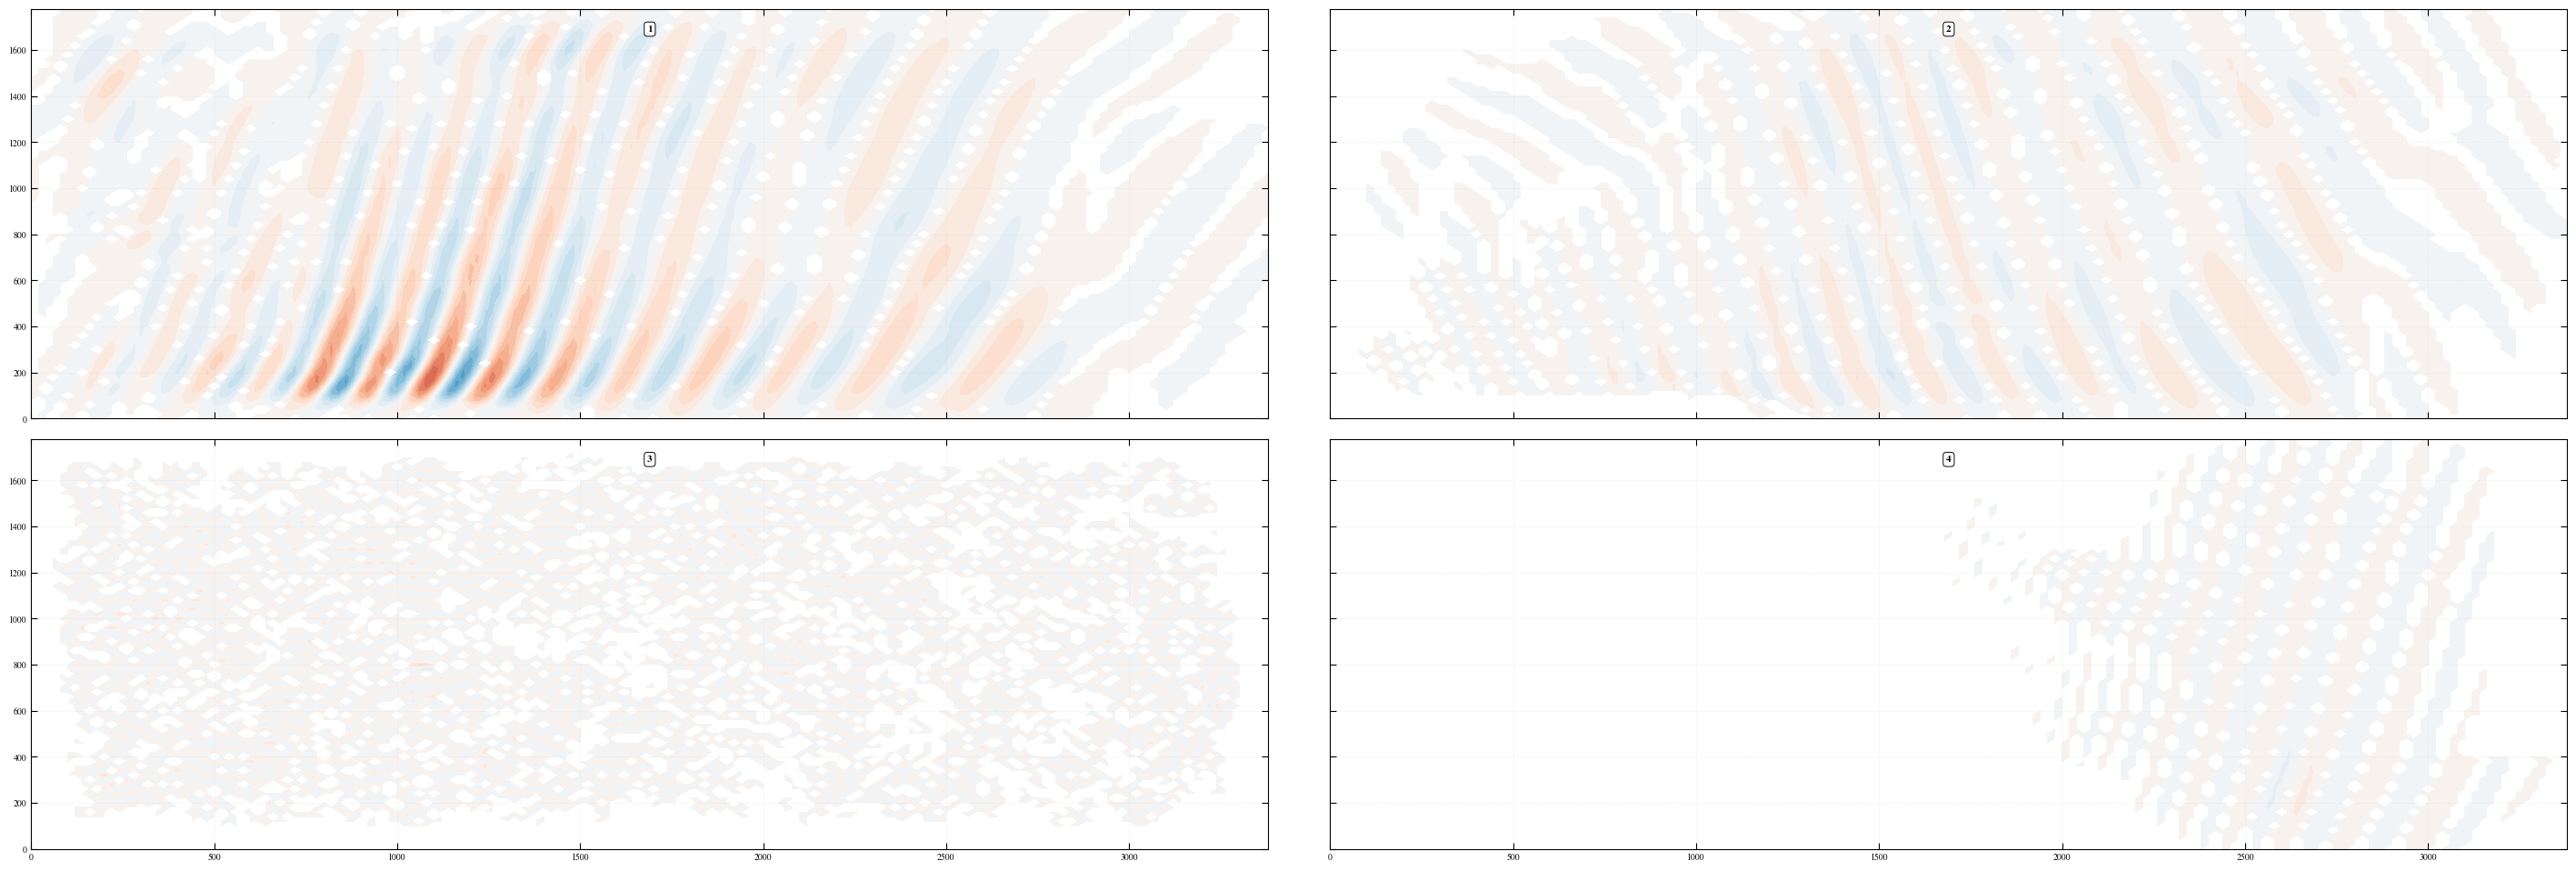

In [61]:
#Mit prominence=3 / sMAD_threshold=3 / eps=0.18 / dj = 1/8
#rad_lev=np.linspace(-3,3,31)
row, col = pt.define_figgrid(recon_WP.shape[0])
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row,col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)
.
for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            #ax[i][j].contourf(the_new_shit[i*col+j,:,:],levels=rad_lev,extend="both",cmap="RdBu_r")
            masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -noise_level*0.1, noise_level*0.1)  
            norm = mcolors.TwoSlopeNorm(vmin=data_lev[0], vcenter=0.0, vmax=data_lev[-1])
            ax[i,j].contourf(x,y,masked.T,levels=data_lev,cmap="RdBu_r",norm=norm,extend='both')
            ax[i,j].text(0.5, 0.95, str(i*col+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

In [139]:
np.min(th_WP)

np.float64(0.00010171543374593028)

In [140]:
np.max(th_WP)

np.float64(4.71238898038469)

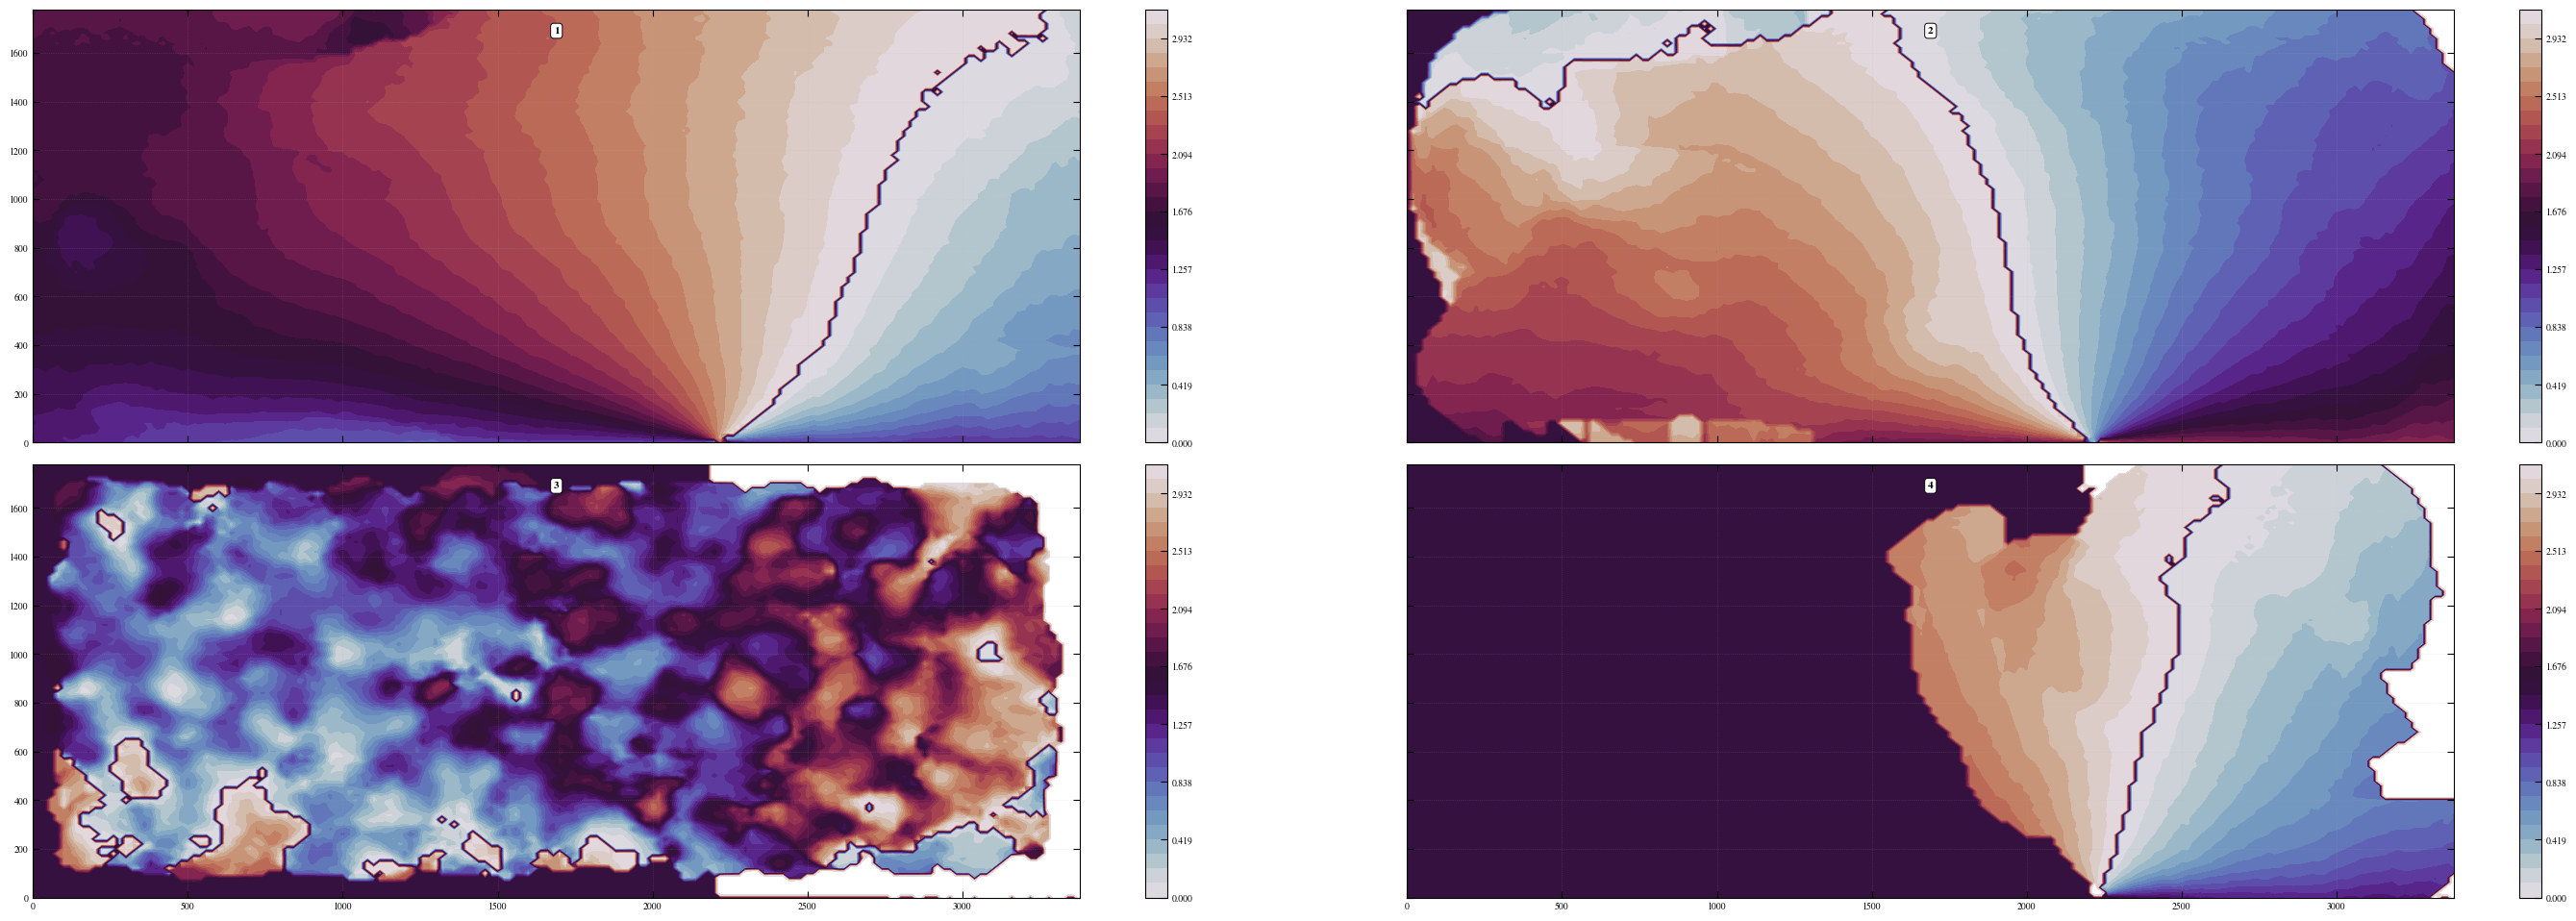

In [132]:
#Mit prominence=3 / sMAD_threshold=3 / eps=0.18 / dj = 1/8
#rad_lev=np.linspace(-3,3,31)
row, col = pt.define_figgrid(recon_WP.shape[0])
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row,col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            #ax[i][j].contourf(the_new_shit[i*col+j,:,:],levels=rad_lev,extend="both",cmap="RdBu_r")
            #masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -noise_level*0.1, noise_level*0.1)  
            #norm = mcolors.TwoSlopeNorm(vmin=data_lev[0], vcenter=0.0, vmax=data_lev[-1])
            plot_data = ax[i,j].contourf(x,y,th_WP[i*col+j,:,:].T,levels=np.linspace(0,np.pi,31),cmap="twilight")
            plt.colorbar(plot_data)
            ax[i,j].text(0.5, 0.95, str(i*coax.quiver(lon, lat, e_along_e, e_along_n, transform=data_crs)l+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

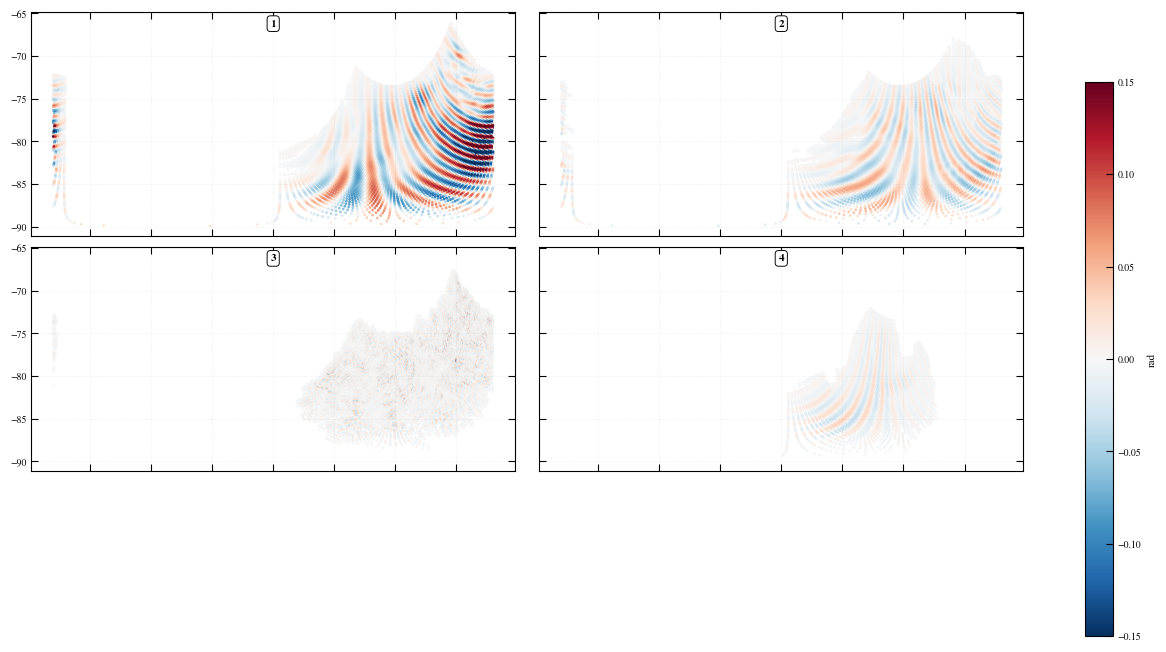

In [62]:
data_lev = np.linspace(-0.5, 0.5, 31)

shape=slice(17_480,17_650)

lon = ds["lon"].isel(NTRACK=shape)
lat = ds["lat"].isel(NTRACK=shape)

lat0 = np.nanmean(lat)

data_aspect = (
    (lon.max() - lon.min()) * np.cos(np.deg2rad(lat0))
    / (lat.max() - lat.min())
)

row, col = pt.define_figgrid(recon_WP.shape[0], data_aspect=float(data_aspect))

gskw = {"hspace": 0.05,"wspace": 0.05,"width_ratios": [1] * col,"height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), gridspec_kw=gskw, sharex=True, sharey=True, squeeze=False)

for i in range(row):
    for j in range(col):
        idx = i * col + j

        if idx < recon_WP.shape[0]:
            masked = np.ma.masked_inside(recon_WP[idx, :, :], -0.001, 0.001)

            sc = ax[i, j].scatter(lon, lat, c=masked, s=1, cmap="RdBu_r", vmin=-0.15, vmax=0.15)

            ax[i, j].text(0.5, 0.95, str(idx + 1), va="center", ha="center", transform=ax[i, j].transAxes, weight="bold", bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})

        else:
            ax[i, j].set_visible(False)

fig.colorbar(sc,ax=ax,orientation="vertical",shrink=0.8,label="rad")

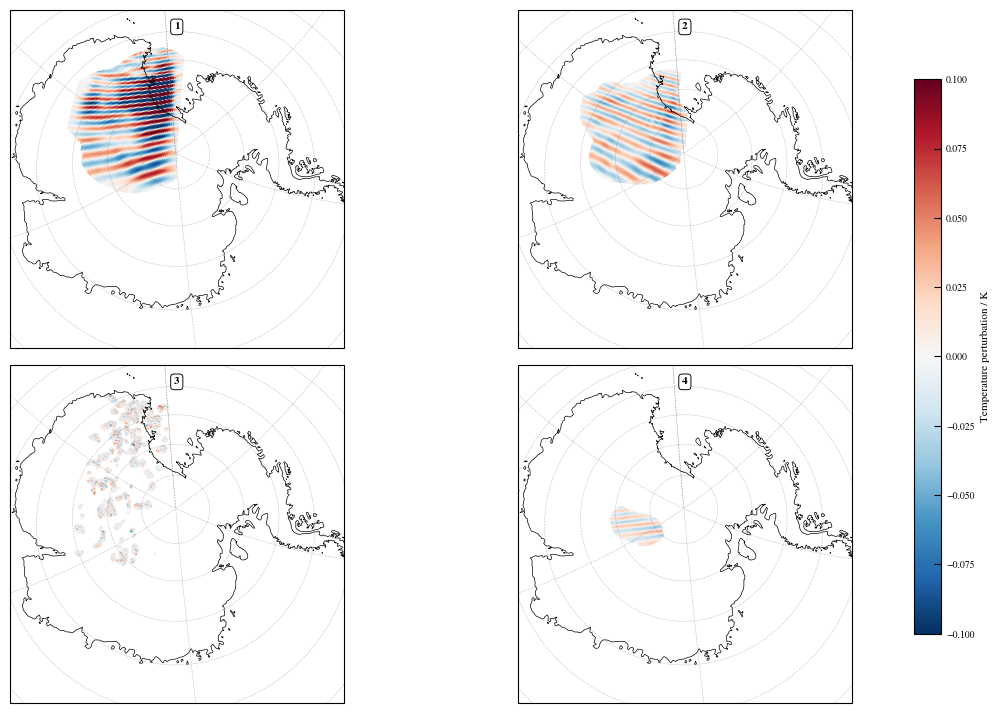

In [76]:
lon = ds["lon"].isel(NTRACK=track_slice)
lat = ds["lat"].isel(NTRACK=track_slice)

# Falls xarray DataArrays: in numpy arrays umwandeln
lon_plot = lon.values
lat_plot = lat.values

# zentraler Längengrad: robuste Variante für 0...360 oder -180...180
def circular_mean_lon(lon_deg):
    lon_rad = np.deg2rad(lon_deg)
    mean_lon = np.rad2deg(
        np.angle(np.nanmean(np.exp(1j * lon_rad)))
    )
    return mean_lon

central_lon = -175#circular_mean_lon(lon_plot) 

# zentrale Breite für die Projektion
# Bei Daten bis zum Südpol ist eine südpolare Projektion sinnvoll.
central_lat = -20.0
proj = ccrs.Stereographic(central_longitude=central_lon, central_latitude=central_lat)
data_crs = ccrs.PlateCarree()

# Für data_aspect brauchst du es hier nicht mehr unbedingt,
# weil die Kartenprojektion die Geometrie übernimmt.
row, col = pt.define_figgrid(recon_WP.shape[0], data_aspect=1.0)

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1] * col, "height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), subplot_kw={"projection": proj}, gridspec_kw=gskw, squeeze=False)

for i in range(row):
    for j in range(col):
        idx = i * col + j

        if idx < recon_WP.shape[0]:
            amp_mask = amp_WP[idx,:,:] > noise_level/2 
            sc = ax[i, j].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[idx,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
            ax[i, j].coastlines(linewidth=0.5)
            gl = ax[i, j].gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")

            ax[i, j].set_extent(
                [
                    np.nanmin(lon_plot),
                    np.nanmax(lon_plot),
                    np.nanmin(lat_plot),
                    np.nanmax(lat_plot),
                ],
                crs=data_crs
            )

            ax[i, j].text(0.5, 0.95, str(idx + 1), va="center", ha="center", transform=ax[i, j].transAxes, weight="bold",
                bbox={
                    "boxstyle": "round",
                    "lw": 0.67,
                    "facecolor": "white",
                    "edgecolor": "black",
                },
            )

        else:
            ax[i, j].set_visible(False)

fig.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8, label="Temperature perturbation / K")

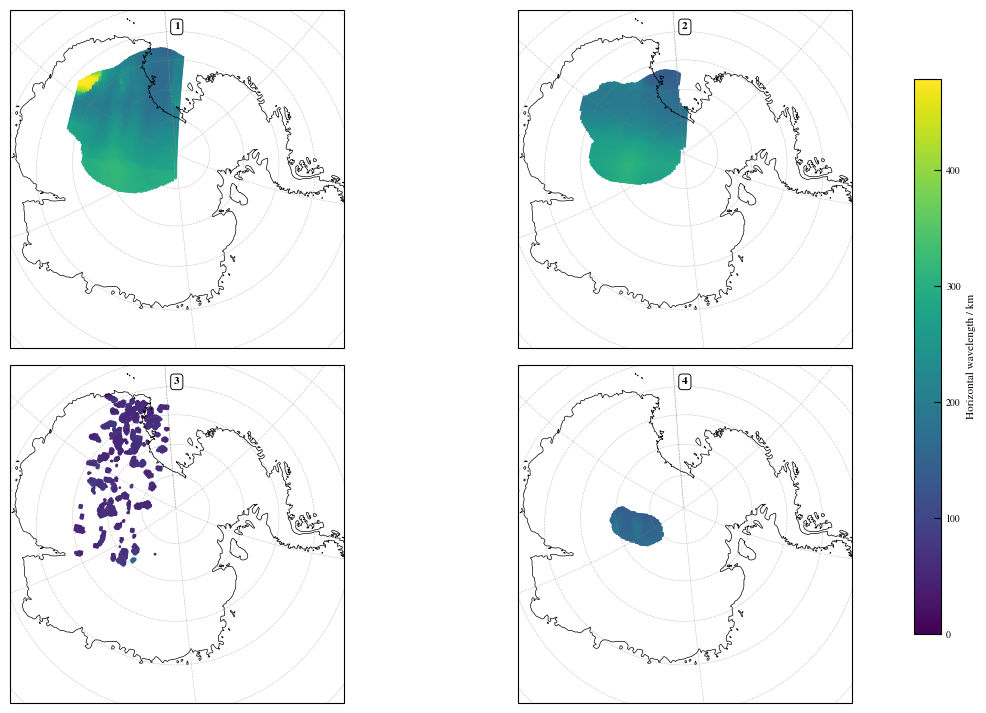

In [73]:
lon = ds["lon"].isel(NTRACK=track_slice)
lat = ds["lat"].isel(NTRACK=track_slice)

# Falls xarray DataArrays: in numpy arrays umwandeln
lon_plot = lon.values
lat_plot = lat.values

# zentraler Längengrad: robuste Variante für 0...360 oder -180...180
def circular_mean_lon(lon_deg):
    lon_rad = np.deg2rad(lon_deg)
    mean_lon = np.rad2deg(
        np.angle(np.nanmean(np.exp(1j * lon_rad)))
    )
    return mean_lon

central_lon = -175#circular_mean_lon(lon_plot) 

# zentrale Breite für die Projektion
# Bei Daten bis zum Südpol ist eine südpolare Projektion sinnvoll.
central_lat = -20.0
proj = ccrs.Stereographic(central_longitude=central_lon, central_latitude=central_lat)
data_crs = ccrs.PlateCarree()

# Für data_aspect brauchst du es hier nicht mehr unbedingt,
# weil die Kartenprojektion die Geometrie übernimmt.
row, col = pt.define_figgrid(recon_WP.shape[0], data_aspect=1.0)

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1] * col, "height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), subplot_kw={"projection": proj}, gridspec_kw=gskw, squeeze=False)

for i in range(row):
    for j in range(col):
        idx = i * col + j

        if idx < recon_WP.shape[0]:
            amp_mask = amp_WP[idx,:,:] > noise_level/2 
            sc = ax[i, j].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_lh[idx,:,:][amp_mask]*1e-3, s=1, vmin=0, vmax=np.max(cwt_result['period'])*1e-3, transform=data_crs, rasterized=True)
            ax[i, j].coastlines(linewidth=0.5)
            gl = ax[i, j].gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")

            ax[i, j].set_extent(
                [
                    np.nanmin(lon_plot),
                    np.nanmax(lon_plot),
                    np.nanmin(lat_plot),
                    np.nanmax(lat_plot),
                ],
                crs=data_crs
            )

            ax[i, j].text(0.5, 0.95, str(idx + 1), va="center", ha="center", transform=ax[i, j].transAxes, weight="bold",
                bbox={
                    "boxstyle": "round",
                    "lw": 0.67,
                    "facecolor": "white",
                    "edgecolor": "black",row, col, f
                },
            )

        else:
            ax[i, j].set_visible(False)

fig.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8, label="Horizontal wavelength / km")

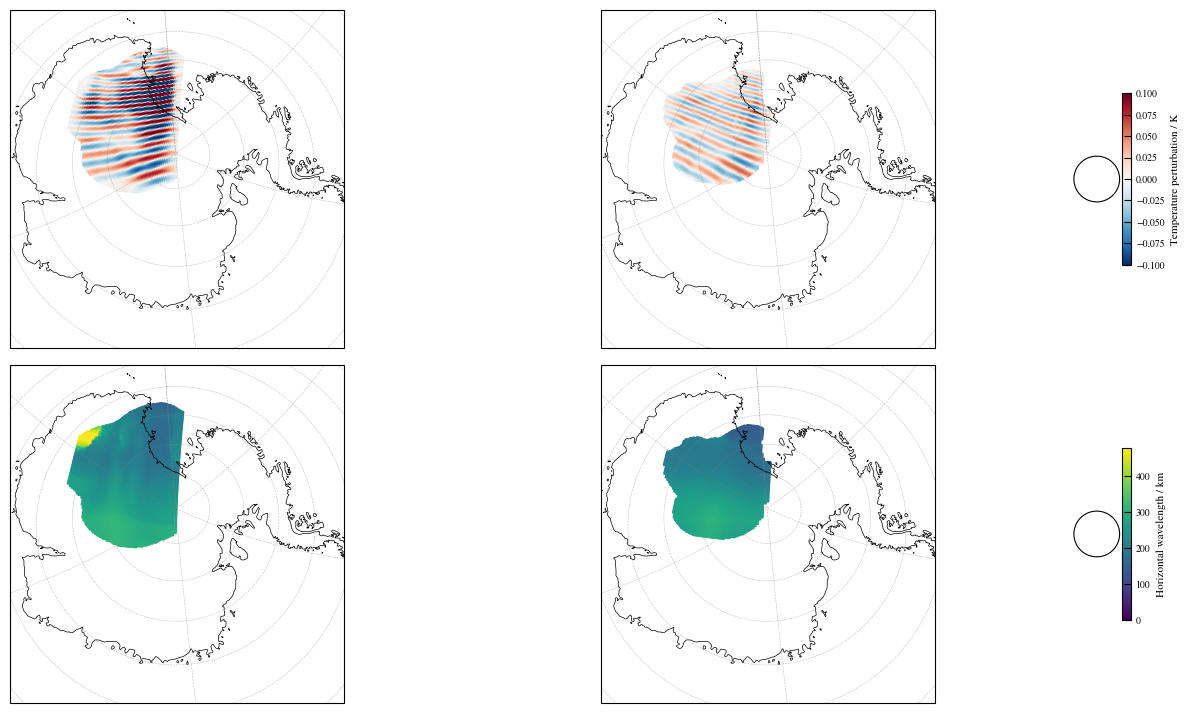

In [94]:
lon = ds["lon"].isel(NTRACK=track_slice)
lat = ds["lat"].isel(NTRACK=track_slice)

# Falls xarray DataArrays: in numpy arrays umwandeln
lon_plot = lon.values
lat_plot = lat.values

# zentraler Längengrad: robuste Variante für 0...360 oder -180...180
def circular_mean_lon(lon_deg):
    lon_rad = np.deg2rad(lon_deg)
    mean_lon = np.rad2deg(
        np.angle(np.nanmean(np.exp(1j * lon_rad)))
    )
    return mean_lon

central_lon = -175#circular_mean_lon(lon_plot) 

# zentrale Breite für die Projektion
# Bei Daten bis zum Südpol ist eine südpolare Projektion sinnvoll.
central_lat = -20.0
proj = ccrs.Stereographic(central_longitude=central_lon, central_latitude=central_lat)
data_crs = ccrs.PlateCarree()

# Für data_aspect brauchst du es hier nicht mehr unbedingt,
# weil die Kartenprojektion die Geometrie übernimmt.
row, col = 2, 3

gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [10, 10, 1], "height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), subplot_kw={"projection": proj}, gridspec_kw=gskw, squeeze=False)

amp_mask = amp_WP[0,:,:] > noise_level/2 
plot_WP_0 = ax[0, 0].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[0,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
plot_lh_0 = ax[1, 0].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=lh2_WP[0,:,:][amp_mask]*1e-3, s=1, vmin=0, vmax=np.max(cwt_result['period']*1e-3), transform=data_crs, rasterized=True)

amp_mask = amp_WP[1,:,:] > noise_level/2 
plot_WP_1 = ax[0, 1].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[1,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
plot_lh_1 = ax[1, 1].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=lh2_WP[1,:,:][amp_mask]*1e-3, s=1, vmin=0, vmax=np.max(cwt_result['period']*1e-3), transform=data_crs, rasterized=True)


for i in range(2):
    for j in range(2):
        ax[i, j].coastlines(linewidth=0.5)
        gl = ax[i, j].gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")

        ax[i, j].set_extent(
            [
                np.nanmin(lon_plot),
                np.nanmax(lon_plot),
                np.nanmin(lat_plot),
                np.nanmax(lat_plot),
            ],
            crs=data_crs
        )
lon = ds["lon"].isel(NTRACK=track_slice)
lat = ds["lat"].isel(NTRACK=track_slice)

# Falls xarray DataArrays: in numpy arrays umwandeln
lon_plot = lon.values
lat_plot = lat.values

# zentraler Längengrad: robuste Variante für 0...360 oder -180...180
def circular_mean_lon(lon_deg):
    lon_rad = np.deg2rad(lon_deg)
    mean_lon = np.rad2deg(
        np.angle(np.nanmean(np.exp(1j * lon_rad)))
    )
    return mean_lon

central_lon = -175#circular_mean_lon(lon_plot) 

# zentrale Breite für die Projektion
# Bei Daten bis zum Südpol ist eine südpolare Projektion sinnvoll.
central_lat = -20.0
proj = ccrs.Stereographic(central_longitude=central_lon, central_latitude=central_lat)
data_crs = ccrs.PlateCarree()

# Für data_aspect brauchst du es hier nicht mehr unbedingt,
# weil die Kartenprojektion die Geometrie übernimmt.
row, col = 2, 3

gskw = {"hspace": 0.05, "wspace": 0.0    k     = np.sqrt(kx**2+ky**2)
    theta = np.arctan2(ky, kx)
    theta = np.pi/2-theta
    theta[theta<0] = 2*np.pi + theta[theta<0]
    
    return 2*np.pi/k, theta5, "width_ratios": [10, 10, 1], "height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), subplot_kw={"projection": proj}, gridspec_kw=gskw, squeeze=False)

amp_mask = amp_WP[0,:,:] > noise_level/2 
plot_WP_0 = ax[0, 0].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[0,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
plot_lh_0 = ax[1, 0].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=th_WP[0,:,:][amp_mask], s=1, vmin=0, vmax=np.pi, cmap='twilight', transform=data_crs, rasterized=True,alpha=0.5)
amp_mask_2 = amp_WP[0][::10,::10] > noise_level/2 
plot_th_0 = ax[1, 0].quiver(lon_plot[::10,::10][amp_mask_2], lat_plot[::10,::10][amp_mask_2], k_east[0,::10,::10][amp_mask_2], k_north[0,::10,::10][amp_mask_2], transform=data_crs, rasterized=True, angles='xy', scale_units='xy')

amp_mask = amp_WP[1,:,:] > noise_level/2 
plot_WP_1 = ax[0, 1].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[1,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
plot_lh_1 = ax[1, 1].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=th_WP[1,:,:][amp_mask], s=1, vmin=0, vmax=np.pi, cmap='twilight', transform=data_crs, rasterized=True,alpha=0.5)
amp_mask_2 = amp_WP[1,::10,::10] > noise_level/2 
plot_th_1 = ax[1, 1].quiver(lon_plot[::10,::10][amp_mask_2], lat_plot[::10,::10][amp_mask_2], k_east[1,::10,::10][amp_mask_2], k_north[1,::10,::10][amp_mask_2], transform=data_crs, rasterized=True, angles='xy', scale_units='xy')
#plot_th_1 = ax[1, 1].quiver(lon_plot[::10,::10][amp_mask_2], lat_plot[::10,::10][amp_mask_2], np.cos(th_WP_3[1,::10,::10])[amp_mask_2], np.sin(th_WP_3[1,::10,::10])[amp_mask_2], transform=data_crs, angles='uv')


for i in range(2):
    for j in range(2):
        ax[i, j].coastlines(linewidth=0.5)
        gl = ax[i, j].gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")

        ax[i, j].set_extent(
            [
                np.nanmin(lon_plot),
                np.nanmax(lon_plot),
                np.nanmin(lat_plot),
                np.nanmax(lat_plot),
            ],
            crs=data_crs
        )

fig.colorbar(plot_WP_0, ax=ax[0,2], orientation="vertical", shrink=0.8, label="Temperature perturbation / K")
fig.colorbar(plot_lh_0, ax=ax[1,2], orientation="vertical", shrink=0.8, label="Horizontal wavelength / km")
fig.colorbar(plot_WP_0, ax=ax[0,2], orientation="vertical", shrink=0.8, label="Temperature perturbation / K")
fig.colorbar(plot_lh_0, ax=ax[1,2], orientation="vertical", shrink=0.8, label="Horizontal wavelength / km")

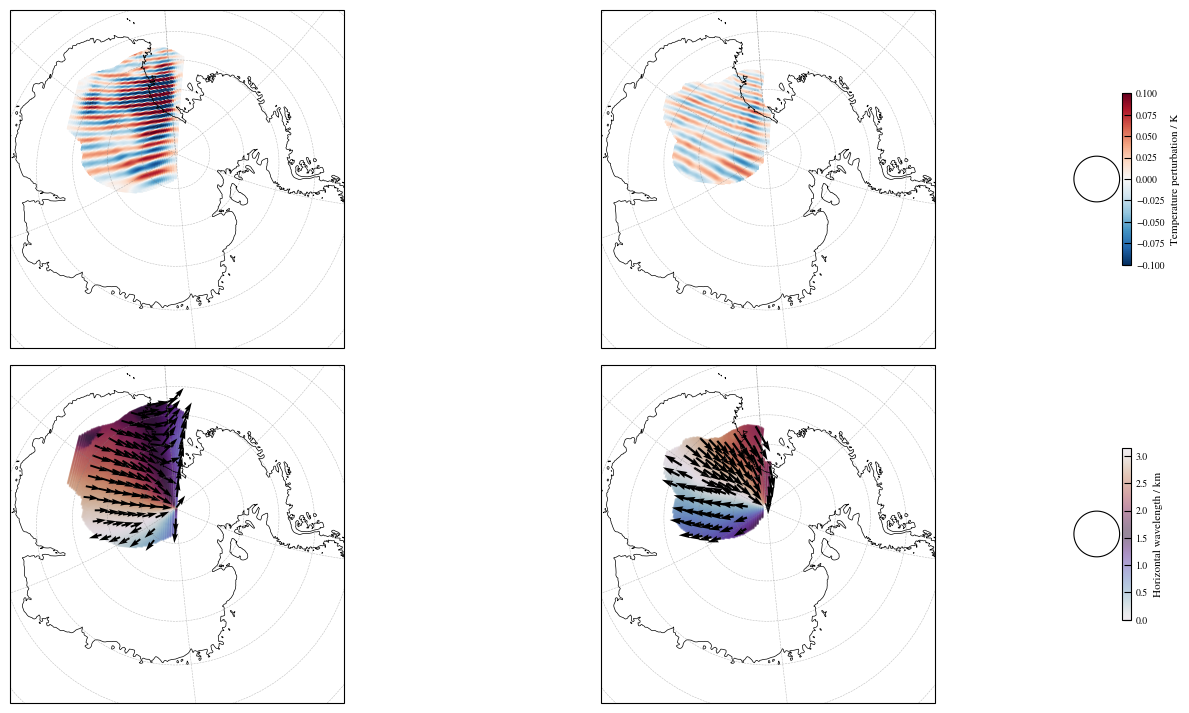

In [136]:
lon = ds["lon"].isel(NTRACK=track_slice)
lat = ds["lat"].isel(NTRACK=track_slice)

# Falls xarray DataArrays: in numpy arrays umwandeln
lon_plot = lon.values
lat_plot = lat.values

# zentraler Längengrad: robuste Variante für 0...360 oder -180...180
def circular_mean_lon(lon_deg):
    lon_rad = np.deg2rad(lon_deg)
    mean_lon = np.rad2deg(
        np.angle(np.nanmean(np.exp(1j * lon_rad)))
    )
    return mean_lon

central_lon = -175#circular_mean_lon(lon_plot) 

# zentrale Breite für die Projektion
# Bei Daten bis zum Südpol ist eine südpolare Projektion sinnvoll.
central_lat = -20.0
proj = ccrs.Stereographic(central_longitude=central_lon, central_latitude=central_lat)
data_crs = ccrs.PlateCarree()

# Für data_aspect brauchst du es hier nicht mehr unbedingt,
# weil die Kartenprojektion die Geometrie übernimmt.
row, col = 2, 3

gskw = {"hspace": 0.05, "wspace": 0.0    k     = np.sqrt(kx**2+ky**2)
    theta = np.arctan2(ky, kx)
    theta = np.pi/2-theta
    theta[theta<0] = 2*np.pi + theta[theta<0]
    
    return 2*np.pi/k, theta5, "width_ratios": [10, 10, 1], "height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), subplot_kw={"projection": proj}, gridspec_kw=gskw, squeeze=False)

amp_mask = amp_WP[0,:,:] > noise_level/2 
plot_WP_0 = ax[0, 0].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[0,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
plot_lh_0 = ax[1, 0].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=th_WP[0,:,:][amp_mask], s=1, vmin=0, vmax=np.pi, cmap='twilight', transform=data_crs, rasterized=True,alpha=0.5)
amp_mask_2 = amp_WP[0][::10,::10] > noise_level/2 
plot_th_0 = ax[1, 0].quiver(lon_plot[::10,::10][amp_mask_2], lat_plot[::10,::10][amp_mask_2], k_east[0,::10,::10][amp_mask_2], k_north[0,::10,::10][amp_mask_2], transform=data_crs, rasterized=True, angles='xy', scale_units='xy')

amp_mask = amp_WP[1,:,:] > noise_level/2 
plot_WP_1 = ax[0, 1].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=recon_WP[1,:,:][amp_mask], s=1, vmin=-0.1, vmax=0.1, cmap='RdBu_r', transform=data_crs, rasterized=True)
plot_lh_1 = ax[1, 1].scatter(lon_plot[amp_mask], lat_plot[amp_mask], c=th_WP[1,:,:][amp_mask], s=1, vmin=0, vmax=np.pi, cmap='twilight', transform=data_crs, rasterized=True,alpha=0.5)
amp_mask_2 = amp_WP[1,::10,::10] > noise_level/2 
plot_th_1 = ax[1, 1].quiver(lon_plot[::10,::10][amp_mask_2], lat_plot[::10,::10][amp_mask_2], k_east[1,::10,::10][amp_mask_2], k_north[1,::10,::10][amp_mask_2], transform=data_crs, rasterized=True, angles='xy', scale_units='xy')
#plot_th_1 = ax[1, 1].quiver(lon_plot[::10,::10][amp_mask_2], lat_plot[::10,::10][amp_mask_2], np.cos(th_WP_3[1,::10,::10])[amp_mask_2], np.sin(th_WP_3[1,::10,::10])[amp_mask_2], transform=data_crs, angles='uv')


for i in range(2):
    for j in range(2):
        ax[i, j].coastlines(linewidth=0.5)
        gl = ax[i, j].gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")

        ax[i, j].set_extent(
            [
                np.nanmin(lon_plot),
                np.nanmax(lon_plot),
                np.nanmin(lat_plot),
                np.nanmax(lat_plot),
            ],
            crs=data_crs
        )

fig.colorbar(plot_WP_0, ax=ax[0,2], orientation="vertical", shrink=0.8, label="Temperature perturbation / K")
fig.colorbar(plot_lh_0, ax=ax[1,2], orientation="vertical", shrink=0.8, label="Horizontal wavelength / km")

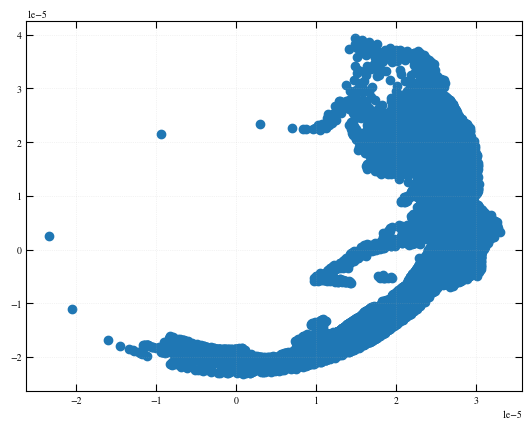

In [102]:
plt.scatter(k_east[0,:,:],k_north[0,:,:])